In [7]:
import pandas as pd
import numpy as np
import sys

sys.path.append("/kaggle/input/datasets/zxcdfg/datasets2")
from utils import weighted_pearson_correlation

In [8]:
df = pd.read_parquet('/kaggle/input/datasets/zxcdfg/datasets2/train.parquet')
df_valid = pd.read_parquet('/kaggle/input/datasets/zxcdfg/datasets2/valid.parquet')

In [9]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import r2_score

# =====================================================
# 1️⃣ CREATE BASE SPREAD FEATURES
# =====================================================

# ---- TRAIN
df["p5_minus_p11"] = df["p5"] - df["p11"]
df["p1_minus_p7"]  = df["p1"] - df["p7"]
df["dp0_minus_dp2"] = df["dp0"] - df["dp2"]

# ---- VALID
df_valid["p5_minus_p11"] = df_valid["p5"] - df_valid["p11"]
df_valid["p1_minus_p7"]  = df_valid["p1"] - df_valid["p7"]
df_valid["dp0_minus_dp2"] = df_valid["dp0"] - df_valid["dp2"]

# =====================================================
# 2️⃣ CREATE dt1
# =====================================================

df["dt1"] = df.groupby("seq_ix")["t1"].diff()
df_valid["dt1"] = df_valid.groupby("seq_ix")["t1"].diff()

# =====================================================
# 3️⃣ CREATE LAG FEATURES (1,2,3) PER SEQUENCE
# =====================================================

BASE_FEATURES = [
    "p5_minus_p11",
    "p1_minus_p7",
    "dp0_minus_dp2"
]

LAGS = [1, 2, 3]

feature_cols = []

for col in BASE_FEATURES:
    
    # include current value
    feature_cols.append(col)
    
    for lag in LAGS:
        lag_col = f"{col}_lag{lag}"
        
        # TRAIN
        df[lag_col] = df.groupby("seq_ix")[col].shift(lag)
        
        # VALID
        df_valid[lag_col] = df_valid.groupby("seq_ix")[col].shift(lag)
        
        feature_cols.append(lag_col)

# =====================================================
# 4️⃣ BUILD TRAIN MATRIX
# =====================================================

X_train = df[feature_cols]
y_train = df["dt1"]

mask_train = X_train.notna().all(axis=1) & y_train.notna()

X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]

# =====================================================
# 5️⃣ TRAIN LIGHTGBM (dt1)
# =====================================================

train_data = lgb.Dataset(X_train, label=y_train)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l2": 1.0,
    "verbosity": -1,
    "seed": 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=300
)


In [21]:
X_valid = df_valid[feature_cols]
y_valid = df_valid["dt1"]

mask_valid = X_valid.notna().all(axis=1) & y_valid.notna()

X_valid_clean = X_valid.loc[mask_valid]
y_valid_clean = y_valid.loc[mask_valid]

y_pred_valid = model.predict(X_valid_clean)

# Save prediction back
df_valid["dt1_pred_lgb"] = np.nan
df_valid.loc[mask_valid, "dt1_pred_lgb"] = y_pred_valid

# Diagnostics for dt1
print("Validation R2 (dt1):", r2_score(y_valid_clean, y_pred_valid))
print("Validation Pearson (dt1):", np.corrcoef(y_valid_clean, y_pred_valid)[0,1])


Validation R2 (dt1): 0.8151544271297047
Validation Pearson (dt1): 0.9033065906160399


In [49]:
df_valid_clean = df_valid[df_valid["dt1_pred_lgb"].notna()].copy()

alpha = 0.1  # tune later

def ema_correct_and_integrate(group):
    
    dt = group["dt1_pred_lgb"].values
    corrected = np.zeros_like(dt)
    
    m = 0.0
    
    for i in range(len(dt)):
        m = alpha * dt[i] + (1 - alpha) * m
        corrected[i] = dt[i] - m
    
    group["dt1_pred_ema_corrected"] = corrected
    group["t1_pred"] = np.cumsum(corrected)
    
    return group


df_valid_clean = (
    df_valid_clean
    .groupby("seq_ix", group_keys=False)
    .apply(ema_correct_and_integrate)
)


/tmp/ipykernel_56/3335126090.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ema_correct_and_integrate)


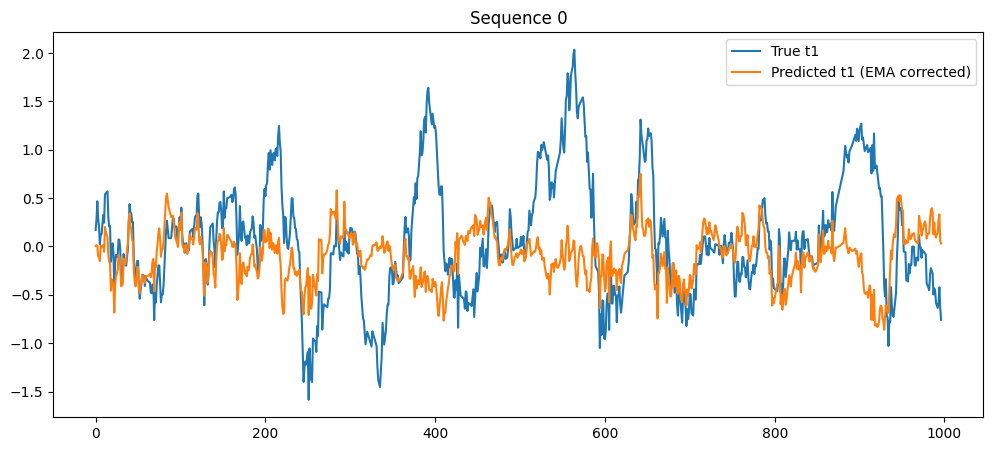

In [50]:
# Choose sequence
seq_to_plot = df_valid_clean["seq_ix"].iloc[0]

tmp = df_valid_clean[df_valid_clean["seq_ix"] == seq_to_plot]

plt.figure(figsize=(12,5))
plt.plot(tmp["t1"].values, label="True t1")
plt.plot(tmp["t1_pred"].values, label="Predicted t1 (EMA corrected)")
plt.legend()
plt.title(f"Sequence {seq_to_plot}")
plt.show()


In [25]:
score = weighted_pearson_correlation(df_valid_clean['t1'], df_valid_clean['t1_pred'])
print(score)

-0.06144918442183761


In [28]:
# --------------------------------------------------
# Running-Mean Bias Correction (Causal)
# --------------------------------------------------

df_valid_bias_corrected = df_valid[df_valid["dt1_pred_lgb"].notna()].copy()

def running_mean_correct_and_integrate(group):
    
    dt = group["dt1_pred_lgb"].values
    corrected = np.zeros_like(dt)
    
    running_sum = 0.0
    
    for i in range(len(dt)):
        running_sum += dt[i]
        mean_t = running_sum / (i + 1)
        corrected[i] = dt[i] - mean_t
    
    group["dt1_pred_rm_corrected"] = corrected
    group["t1_pred_rm"] = np.cumsum(corrected)
    
    return group


df_valid_bias_corrected = (
    df_valid_bias_corrected
    .groupby("seq_ix", group_keys=False)
    .apply(running_mean_correct_and_integrate)
)


/tmp/ipykernel_56/1980407032.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(running_mean_correct_and_integrate)


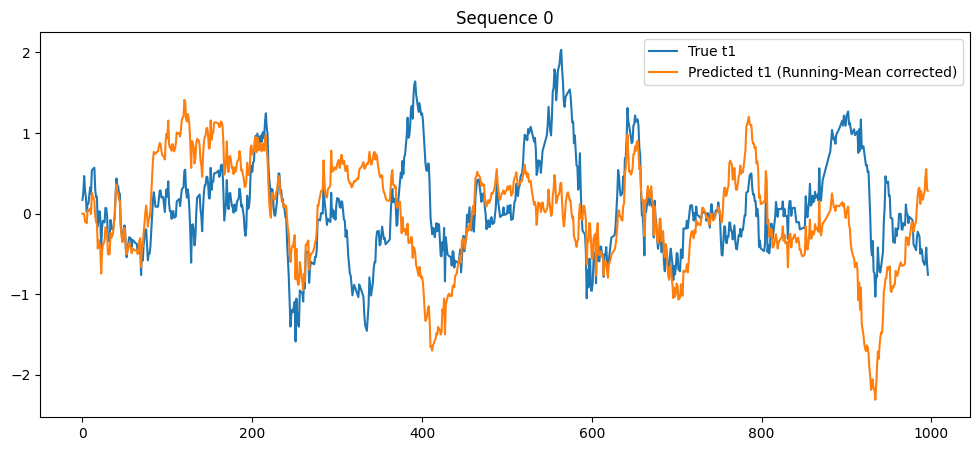

In [55]:
seq_to_plot = df_valid_bias_corrected["seq_ix"].iloc[15]

tmp = df_valid_bias_corrected[
    df_valid_bias_corrected["seq_ix"] == seq_to_plot
]

plt.figure(figsize=(12,5))
plt.plot(tmp["t1"].values, label="True t1")
plt.plot(tmp["t1_pred_rm"].values, label="Predicted t1 (Running-Mean corrected)")
plt.legend()
plt.title(f"Sequence {seq_to_plot}")
plt.show()


In [53]:
score = weighted_pearson_correlation(df_valid_clean['t1'], df_valid_bias_corrected['t1_pred_rm'])
print(score)

-5.412881499894934e-05


In [56]:
for lag in range(-5, 6):
    corr = np.corrcoef(
        tmp["t1"].values[5:-5],
        np.roll(tmp["t1_pred_rm"].values, lag)[5:-5]
    )[0,1]
    print(lag, corr)


-5 0.10788092908834383
-4 0.13137320541758457
-3 0.15625130968287668
-2 0.1855965122662982
-1 0.2173748624518115
0 0.25508057717010735
1 0.24730585488538726
2 0.2427882087824886
3 0.23842354333883864
4 0.2366462362515766
5 0.23474891326405045


In [77]:
# -------------------------------------------
# Slow EMA Trend Removal + Reconstruction
# -------------------------------------------

import numpy as np

df_valid_filtered = df_valid[df_valid["dt1_pred_lgb"].notna()].copy()

def slow_ema_filter_and_integrate(group, span=1000):
    
    dt = group["dt1_pred_lgb"]
    
    # Very slow EMA (trend component)
    slow_ema = dt.ewm(span=span, adjust=False).mean()
    
    # Remove only ultra-low-frequency component
    dt_filtered = dt - slow_ema
    
    group["dt1_pred_filtered"] = dt_filtered
    group["t1_pred_filtered"] = dt_filtered.cumsum()
    
    return group


df_valid_filtered = (
    df_valid_filtered
    .groupby("seq_ix", group_keys=False)
    .apply(slow_ema_filter_and_integrate)
)


/tmp/ipykernel_56/69994230.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slow_ema_filter_and_integrate)


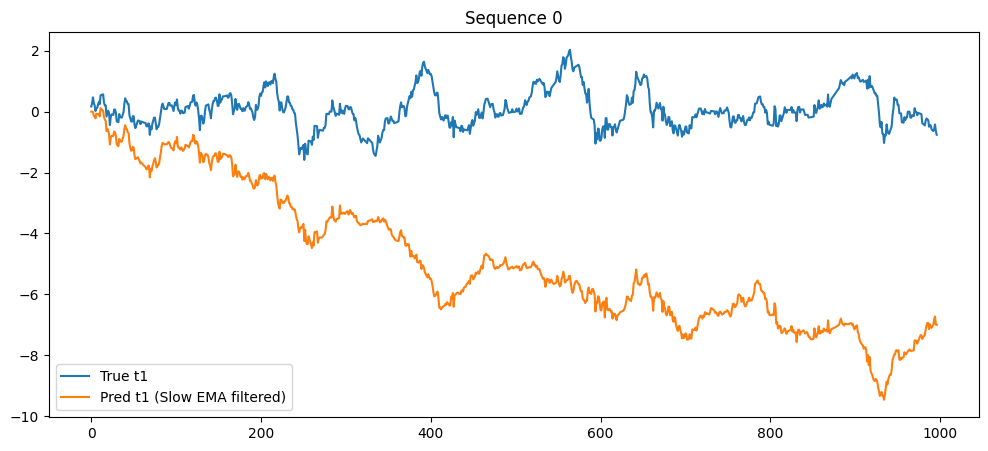

In [78]:
seq_to_plot = df_valid_filtered["seq_ix"].iloc[0]

tmp = df_valid_filtered[df_valid_filtered["seq_ix"] == seq_to_plot]

plt.figure(figsize=(12,5))
plt.plot(tmp["t1"].values, label="True t1")
plt.plot(tmp["t1_pred_filtered"].values, label="Pred t1 (Slow EMA filtered)")
plt.legend()
plt.title(f"Sequence {seq_to_plot}")
plt.show()


In [79]:
# -------------------------------------------
# Leaky Integration (Causal Drift Control)
# -------------------------------------------

df_valid_leaky = df_valid[df_valid["dt1_pred_lgb"].notna()].copy()

def leaky_integrate(group, decay=0.997):
    
    dt = group["dt1_pred_lgb"].values
    t_pred = np.zeros_like(dt)
    
    for i in range(1, len(dt)):
        t_pred[i] = decay * t_pred[i-1] + dt[i]
    
    group["t1_pred_leaky"] = t_pred
    
    return group


df_valid_leaky = (
    df_valid_leaky
    .groupby("seq_ix", group_keys=False)
    .apply(leaky_integrate)
)


/tmp/ipykernel_56/2983165111.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(leaky_integrate)


In [84]:
df_valid_leaky['t1_detrended'] = df_valid_leaky['t1_pred_leaky'] - df_valid_leaky['t1_pred_leaky'].shift(100)

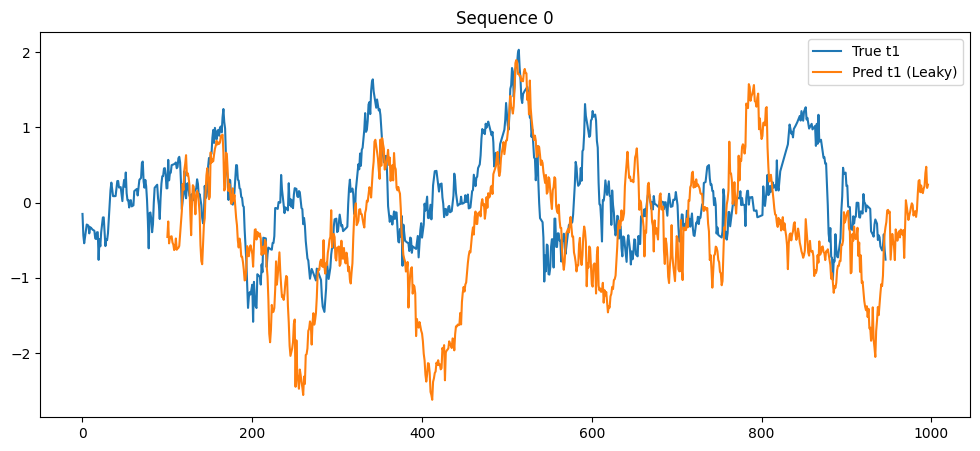

In [96]:
seq_to_plot = df_valid_leaky["seq_ix"].iloc[0]

tmp = df_valid_leaky[df_valid_leaky["seq_ix"] == seq_to_plot]

plt.figure(figsize=(12,5))
plt.plot(tmp["t1"].shift(-50).values, label="True t1")
plt.plot(tmp["t1_detrended"].values, label="Pred t1 (Leaky)")
plt.legend()
plt.title(f"Sequence {seq_to_plot}")
plt.show()


In [97]:
score_shift = weighted_pearson_correlation(df_valid_leaky['t1_detrended'].shift(-50), df_valid_leaky['t1'])
score_shift

-0.42310065990514173

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------
# 1️⃣ Prepare raw reconstructed t1
# -------------------------------------------

df_seq = df_valid[df_valid["dt1_pred_lgb"].notna()].copy()

df_seq["t1_pred_raw"] = (
    df_seq
    .groupby("seq_ix")["dt1_pred_lgb"]
    .cumsum()
)


In [102]:
rotated_all = []

for seq, group in df_seq.groupby("seq_ix"):
    
    y_true = group["t1"].values
    y_pred = group["t1_pred_raw"].values
    x = np.arange(len(y_true))
    
    if len(x) < 5:
        continue
    
    # Fit slopes
    slope_true = np.polyfit(x, y_true, 1)[0]
    slope_pred = np.polyfit(x, y_pred, 1)[0]
    
    angle_true = np.arctan(slope_true)
    angle_pred = np.arctan(slope_pred)
    angle_diff = angle_true - angle_pred
    
    # Pivot at first point
    pivot_y = y_pred[0]
    x_shift = x
    y_shift = y_pred - pivot_y
    
    cos_a = np.cos(angle_diff)
    sin_a = np.sin(angle_diff)
    
    y_rot = x_shift * sin_a + y_shift * cos_a
    y_rot = y_rot + pivot_y
    
    rotated_all.append(
        pd.DataFrame({
            "t1_true": y_true,
            "t1_rotated": y_rot
        })
    )

rotated_df = pd.concat(rotated_all, ignore_index=True)

weighted_corr_global = weighted_pearson_correlation(
    rotated_df["t1_true"].values,
    rotated_df["t1_rotated"].values
)

print("Global Weighted Pearson (Rotated):", weighted_corr_global)


Global Weighted Pearson (Rotated): 0.1872603293069954


In [99]:
# -------------------------------------------
# 7️⃣ Weighted Pearson (Rotated vs True)
# -------------------------------------------

weighted_corr_rotated = weighted_pearson_correlation(
    y_true,
    y_pred_rotated
)




In [100]:
weighted_corr_raw = weighted_pearson_correlation(
    y_true,
    y_pred
)

print("Weighted Pearson (Raw):", weighted_corr_raw)
print("Weighted Pearson (Rotated):", weighted_corr_rotated)


Weighted Pearson (Raw): -0.2467018859505436
Weighted Pearson (Rotated): 0.35390613603087023


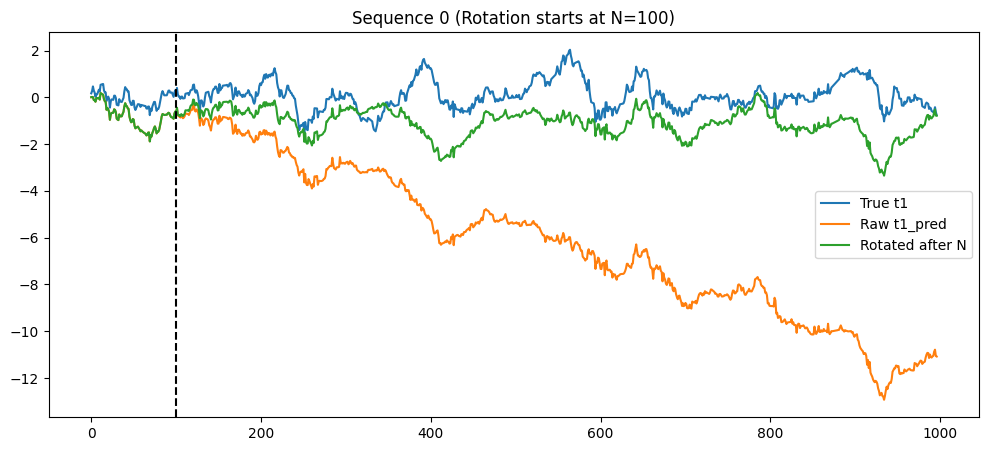

Weighted Pearson after rotation (N=100): -0.021331191541238827


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# CONFIGURABLE WINDOW SIZE
# --------------------------------------------
N = 100   # change this freely

# --------------------------------------------
# Step 1: Raw reconstruction
# --------------------------------------------

df_seq = df_valid[df_valid["dt1_pred_lgb"].notna()].copy()

df_seq["t1_pred_raw"] = (
    df_seq
    .groupby("seq_ix")["dt1_pred_lgb"]
    .cumsum()
)

rotated_all = []
example_plot_done = False

# --------------------------------------------
# Step 2: Rotate only AFTER step N
# --------------------------------------------

for seq, group in df_seq.groupby("seq_ix"):
    
    group = group.copy()
    
    y_true = group["t1"].values
    y_pred = group["t1_pred_raw"].values
    x = np.arange(len(y_true))
    
    if len(x) <= N:
        continue
    
    # ---- compute slope using first N points only
    slope_pred = np.polyfit(x[:N], y_pred[:N], 1)[0]
    
    angle_pred = np.arctan(slope_pred)
    angle_diff = -angle_pred  # rotate toward flat
    
    # ---- pivot at step N
    pivot_x = N
    pivot_y = y_pred[N]
    
    y_rot = y_pred.copy()
    
    # rotate only points AFTER N
    x_after = x[N:] - pivot_x
    y_after = y_pred[N:] - pivot_y
    
    cos_a = np.cos(angle_diff)
    sin_a = np.sin(angle_diff)
    
    y_rot_after = x_after * sin_a + y_after * cos_a
    y_rot_after = y_rot_after + pivot_y
    
    y_rot[N:] = y_rot_after
    
    group["t1_pred_rotated"] = y_rot
    
    rotated_all.append(group[["t1", "t1_pred_rotated"]])
    
    # ---- Plot one example
    if not example_plot_done:
        plt.figure(figsize=(12,5))
        plt.plot(x, y_true, label="True t1")
        plt.plot(x, y_pred, label="Raw t1_pred")
        plt.plot(x, y_rot, label="Rotated after N")
        plt.axvline(N, linestyle="--", color="black")
        plt.legend()
        plt.title(f"Sequence {seq} (Rotation starts at N={N})")
        plt.show()
        example_plot_done = True


# --------------------------------------------
# Step 3: Global Weighted Pearson
# --------------------------------------------

rotated_df = pd.concat(rotated_all, ignore_index=True)

weighted_corr_rotated = weighted_pearson_correlation(
    rotated_df["t1"].values,
    rotated_df["t1_pred_rotated"].values
)

print(f"Weighted Pearson after rotation (N={N}):", weighted_corr_rotated)


In [108]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import r2_score

# --------------------------------------------
# Spread Features
# --------------------------------------------

for data in [df, df_valid]:
    data["p5_minus_p11"] = data["p5"] - data["p11"]
    data["p1_minus_p7"]  = data["p1"] - data["p7"]
    data["dp0_minus_dp2"] = data["dp0"] - data["dp2"]


In [109]:
BASE_FEATURES = [
    "p5_minus_p11",
    "p1_minus_p7",
    "dp0_minus_dp2"
]

LAGS = [1, 2, 3]
feature_cols = []

for col in BASE_FEATURES:
    
    feature_cols.append(col)
    
    for lag in LAGS:
        lag_col = f"{col}_lag{lag}"
        
        df[lag_col] = df.groupby("seq_ix")[col].shift(lag)
        df_valid[lag_col] = df_valid.groupby("seq_ix")[col].shift(lag)
        
        feature_cols.append(lag_col)


In [110]:
ROLL_WINDOWS = [20, 50, 100]

for col in BASE_FEATURES:
    
    for window in ROLL_WINDOWS:
        
        roll_col = f"{col}_rollsum_{window}"
        
        df[roll_col] = (
            df.groupby("seq_ix")[col]
            .transform(lambda x: x.rolling(window, min_periods=1).sum())
        )
        
        df_valid[roll_col] = (
            df_valid.groupby("seq_ix")[col]
            .transform(lambda x: x.rolling(window, min_periods=1).sum())
        )
        
        feature_cols.append(roll_col)


In [111]:
X_train = df[feature_cols]
y_train = df["t1"]

mask_train = X_train.notna().all(axis=1) & y_train.notna()

X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]

train_data = lgb.Dataset(X_train, label=y_train)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,           # slightly higher capacity
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l2": 0.5,
    "verbosity": -1,
    "seed": 42
}

model = lgb.train(params, train_data, num_boost_round=400)


In [113]:
X_valid = df_valid[feature_cols]
y_valid = df_valid["t1"]

mask_valid = X_valid.notna().all(axis=1) & y_valid.notna()

X_valid_clean = X_valid.loc[mask_valid]
y_valid_clean = y_valid.loc[mask_valid]

y_pred_valid = model.predict(X_valid_clean)


In [114]:
# Basic diagnostics
print("Validation R2:", r2_score(y_valid_clean, y_pred_valid))
print("Validation Pearson:", np.corrcoef(y_valid_clean, y_pred_valid)[0,1])
print("Validation Spearman:",
      pd.Series(y_valid_clean.values).corr(pd.Series(y_pred_valid), method="spearman"))

# Weighted Pearson (your leaderboard metric)
weighted_corr = weighted_pearson_correlation(
    y_valid_clean.values,
    y_pred_valid
)

print("Validation Weighted Pearson:", weighted_corr)


Validation R2: -0.004440093542515955
Validation Pearson: 0.0380598739706253
Validation Spearman: 0.044244224070210184
Validation Weighted Pearson: 0.06830730197070425
